# TechBazar savdo ma'lumotlari tahlili

Kamola so'ragan edi: qaysi mahsulotlarga ko'proq pul tikish kerak.
Ma'lumotni ko'rib chiqamiz, tozalaymiz va kategoriyalar bo'yicha foydani solishtiramiz.

In [1]:
# kutubxonalarni yuklaymiz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("dataset.csv")
df.head()

,product_id,category,region,store_type,year,month,avg_unit_price,units_sold,returns,discount_pct,promo_active,customer_rating,competitor_price_index,marketing_spend,monthly_revenue
0,P1001,smartphones,Tashkent,offline,2023,1,581.95,298,21,28.5,True,4.6,0.86,5743.41,124478.76
1,P1002,smartphones,Tashkent,offline,2023,2,562.49,291,16,19.4,True,4.5,1.13,3337.52,124675.91
2,P1003,smartphones,Tashkent,both,2023,3,502.26,361,14,4.8,False,4.4,1.15,10194.22,165918.58
3,P1004,smartphones,Tashkent,both,2023,4,577.21,408,21,1.9,False,4.4,1.14,13449.78,219136.04
4,P1005,smartphones,Tashkent,both,2023,5,469.80,449,16,1.1,False,4.5,0.89,7736.95,217280.60


## Ma'lumotga qaraymiz

In [2]:
print("shakli:", df.shape)
df.info()

shakli: (2400, 15)
<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              2400 non-null   str    
 1   category                2400 non-null   str    
 2   region                  2400 non-null   str    
 3   store_type              2400 non-null   str    
 4   year                    2400 non-null   int64  
 5   month                   2400 non-null   int64  
 6   avg_unit_price          2400 non-null   float64
 7   units_sold              2400 non-null   int64  
 8   returns                 2400 non-null   int64  
 9   discount_pct            2400 non-null   float64
 10  promo_active            2304 non-null   object 
 11  customer_rating         2328 non-null   float64
 12  competitor_price_index  2352 non-null   float64
 13  marketing_spend         2400 non-null   float64
 14  monthly_revenue         2400 non

In [3]:
df.describe()

,year,month,avg_unit_price,units_sold,returns,discount_pct,customer_rating,competitor_price_index,marketing_spend,monthly_revenue
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2328.000000,2352.000000,2400.000000,2.400000e+03
mean,2023.500000,6.500000,268.426929,237.990417,11.429583,9.076833,4.114046,1.027151,2228.115308,3.910945e+04
std,0.500104,3.452772,230.588458,249.114313,13.679169,10.840218,0.350572,0.100370,2935.732043,5.192661e+04
min,2023.000000,1.000000,11.350000,27.000000,-5.000000,0.000000,3.000000,0.850000,49.550000,1.626530e+03
25%,2023.000000,3.750000,88.610000,76.750000,3.000000,1.700000,3.900000,0.940000,637.975000,1.234183e+04
50%,2023.500000,6.500000,177.625000,174.000000,7.000000,3.500000,4.100000,1.030000,1304.965000,2.504608e+04
75%,2024.000000,9.250000,422.410000,294.000000,15.000000,17.700000,4.400000,1.110000,2462.125000,4.070096e+04
max,2024.000000,12.000000,884.170000,1896.000000,113.000000,35.000000,5.000000,1.200000,24229.630000,1.278254e+06


In [4]:
# qaysi ustunda bo'sh qiymat bor
df.isnull().sum()

product_id                 0
category                   0
region                     0
store_type                 0
year                       0
month                      0
avg_unit_price             0
units_sold                 0
returns                    0
discount_pct               0
promo_active              96
customer_rating           72
competitor_price_index    48
marketing_spend            0
monthly_revenue            0
dtype: int64

In [5]:
print("kategoriyalar:", df["category"].unique())
print("hududlar:", df["region"].unique())
print("yillar:", df["year"].unique())

kategoriyalar: <ArrowStringArray>
[    'smartphones',  'wireless_audio',          'gaming',      'smart_home',
 'cables_chargers', 'storage_devices',         'laptops',         'tablets',
       'wearables',         'cameras']
Length: 10, dtype: str
hududlar: <ArrowStringArray>
['Tashkent', 'Samarkand', 'Bukhara', 'Andijan', 'Namangan']
Length: 5, dtype: str
yillar: [2023 2024]


In [6]:
# qaysi kategoriyadan qancha yozuv bor
df["category"].value_counts()

category
smartphones        240
wireless_audio     240
gaming             240
smart_home         240
cables_chargers    240
storage_devices    240
laptops            240
tablets            240
wearables          240
cameras            240
Name: count, dtype: int64

## Daromad ustunini tekshiramiz

In [7]:
# daromad qanday hisoblanganini ko'ramiz
# narx * dona ga tengmi?
df["narx_dona"] = df["avg_unit_price"] * df["units_sold"]
df[["monthly_revenue", "narx_dona", "discount_pct"]].head(10)

,monthly_revenue,narx_dona,discount_pct
0,124478.76,173421.10,28.5
1,124675.91,163684.59,19.4
2,165918.58,181315.86,4.8
3,219136.04,235501.68,1.9
4,217280.60,210940.20,1.1
5,121987.51,133760.00,1.3
6,114959.01,128157.56,4.9
7,103496.24,168460.50,33.9
8,133330.75,142477.25,1.2
9,144190.92,148066.26,0.2


In [8]:
# chegirma hisobga olinganidan keyin daromadga tenglashadi
df["chegirmali"] = df["narx_dona"] * (1 - df["discount_pct"] / 100)

# nisbatini ko'ramiz
df["nisbat"] = df["monthly_revenue"] / df["chegirmali"]
df["nisbat"].describe()

count    2400.000000
mean        0.992010
std         0.398724
min         0.920690
25%         0.944444
50%         0.964806
75%         1.000001
max        10.140845
Name: nisbat, dtype: float64

In [9]:
# 1.0 ga yaqin chiqdi, lekin biroz pastroq
# sababi: qaytarilgan tovarlar daromaddan ayirilmagan bo'lishi mumkin
# qaytarilgan tovar ustunini ko'ramiz
df[["units_sold", "returns", "monthly_revenue"]].head(10)

,units_sold,returns,monthly_revenue
0,298,21,124478.76
1,291,16,124675.91
2,361,14,165918.58
3,408,21,219136.04
4,449,16,217280.60
5,250,19,121987.51
6,229,13,114959.01
7,326,23,103496.24
8,265,14,133330.75
9,289,7,144190.92


In [10]:
# bir qator g'alati katta daromad bor, tekshiramiz
df["gross"] = df["avg_unit_price"] * df["units_sold"]
gala = df[df["monthly_revenue"] > 3 * df["gross"]]
print("g'alati qatorlar soni:", len(gala))
gala[["product_id", "category", "region", "monthly_revenue", "gross"]]

g'alati qatorlar soni: 5


,product_id,category,region,monthly_revenue,gross
121,P1122,smartphones,Bukhara,1278253.5,126302.61
472,P1473,wireless_audio,Namangan,252633.0,28553.69
1008,P2009,cables_chargers,Samarkand,108977.2,11831.56
1287,P2288,storage_devices,Samarkand,35063.0,3658.40
1421,P2422,storage_devices,Namangan,73218.0,7882.05


In [11]:
# shuningdek manfiy qaytarishlar ham bor
df[df["returns"] < 0][["product_id", "category", "returns"]]

,product_id,category,returns
159,P1160,smartphones,-4
377,P1378,wireless_audio,-3
2270,P3271,cameras,-5


## Xatolarni to'g'rilaymiz

Yuqoridagi tekshiruvdan chiqdi:
1. Ba'zi mahsulotlarda daromad juda katta yozilgan (vergul xatosi bo'lsa kerak).
2. Qaytarilgan tovarlar daromaddan ayirilmagan.
3. Bir nechta qatorda qaytarish soni manfiy.

Shularni tuzatib, sof foydani hisoblaymiz.

In [12]:
# 1. g'alati katta daromadlarni to'g'rilaymiz
for i in gala.index:
    df.loc[i, "monthly_revenue"] = df.loc[i, "gross"] * (1 - df.loc[i, "discount_pct"] / 100)

print("to'g'rilandi:", len(gala))

to'g'rilandi: 5


In [13]:
# 2. qaytarilgan tovar zararini hisoblaymiz
df["qaytish_zarari"] = df["returns"] * df["avg_unit_price"] * (1 - df["discount_pct"] / 100)

# 3. sof foyda = daromad - qaytish zarari - marketing
df["sof_foyda"] = df["monthly_revenue"] - df["qaytish_zarari"] - df["marketing_spend"]

# o'zbekchalashtiramiz (grafiklar uchun)
df["kategoria_uz"] = df["category"]

print("umumiy sof foyda:", f"${df['sof_foyda'].sum():,.0f}")
print("umumiy qaytish zarari:", f"${df['qaytish_zarari'].sum():,.0f}")
df[["product_id", "monthly_revenue", "qaytish_zarari", "marketing_spend", "sof_foyda"]].head()

umumiy sof foyda: $82,431,890
umumiy qaytish zarari: $4,511,211


,product_id,monthly_revenue,qaytish_zarari,marketing_spend,sof_foyda
0,P1001,124478.76,8737.97925,5743.41,109997.37075
1,P1002,124675.91,7253.87104,3337.52,114084.51896
2,P1003,165918.58,6694.12128,10194.22,149030.23872
3,P1004,219136.04,11891.10321,13449.78,193795.15679
4,P1005,217280.60,7434.11520,7736.95,202109.53480


## Kategoriyalar bo'yicha solishtiramiz

In [14]:
# kategoriya bo'yicha yig'amiz
kategoriya = df.groupby("category").agg({
    "sof_foyda": "sum",
    "units_sold": "sum",
    "returns": "sum"
}).reset_index()

# har bir donadan qolgan foyda
kategoriya["birlik_foydasi"] = kategoriya["sof_foyda"] / kategoriya["units_sold"]
kategoriya = kategoriya.sort_values("sof_foyda", ascending=False)
kategoriya

,category,sof_foyda,units_sold,returns,birlik_foydasi
5,smartphones,3.437457e+07,85114,4212,403.865098
3,laptops,1.143790e+07,19145,838,597.435164
2,gaming,8.998896e+06,55547,2641,162.005071
7,tablets,6.596948e+06,27543,1210,239.514493
9,wireless_audio,6.171847e+06,90594,4512,68.126444
8,wearables,5.203932e+06,43409,2142,119.881408
1,cameras,3.933088e+06,11795,500,333.453860
4,smart_home,2.443430e+06,27767,1245,87.997634
0,cables_chargers,1.853561e+06,167995,8174,11.033427
6,storage_devices,1.417718e+06,42268,1957,33.541169


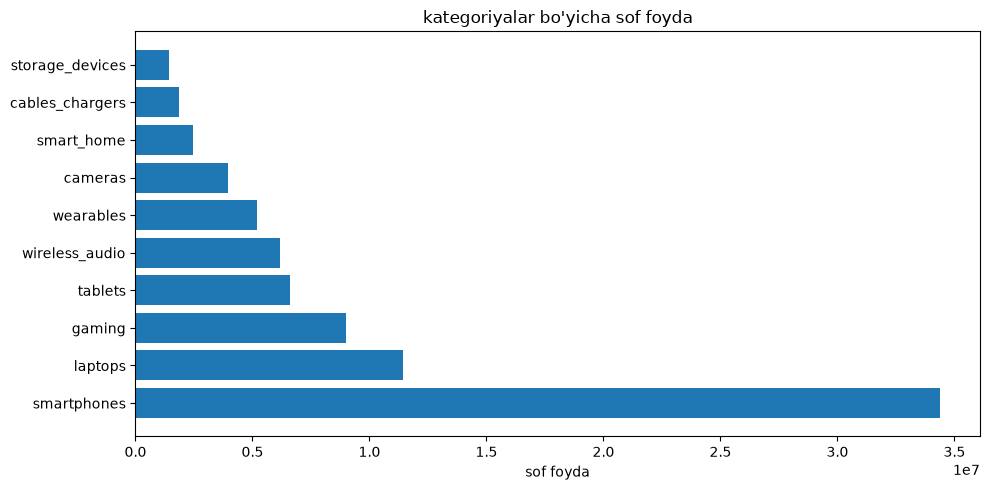

In [15]:
# sof foyda bo'yicha grafik
plt.figure(figsize=(10, 5))
plt.barh(kategoriya["category"], kategoriya["sof_foyda"])
plt.xlabel("sof foyda")
plt.title("kategoriyalar bo'yicha sof foyda")
plt.tight_layout()
plt.show()

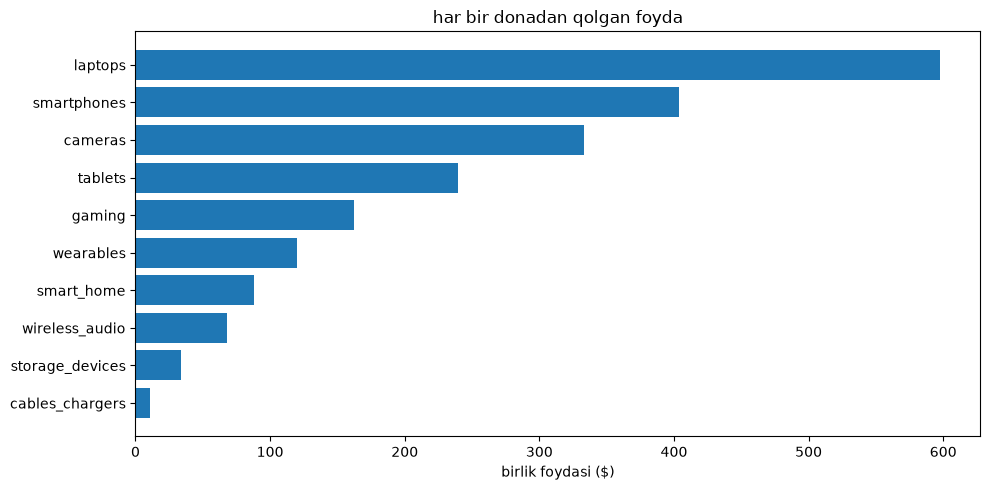

In [16]:
# birlik foydasi bo'yicha grafik
kategoriya2 = kategoriya.sort_values("birlik_foydasi")
plt.figure(figsize=(10, 5))
plt.barh(kategoriya2["category"], kategoriya2["birlik_foydasi"])
plt.xlabel("birlik foydasi ($)")
plt.title("har bir donadan qolgan foyda")
plt.tight_layout()
plt.show()

Ko'rinib turibdiki, ko'p sotiladigan kabel kabi tovarlardan foyda juda kam.
Noutbuk esa kam sotiladi, lekin har donasidan yaxshi foyda qoladi.

In [17]:
# Kamola aytgan edi: aqlli uy kam sotiladi lekin marjasi yaxshi,
# simsiz audio ko'p sotiladi lekin foydasi kam
# tekshiramiz
for k in ["smart_home", "wireless_audio"]:
    q = df[df["category"] == k]
    print(k, ":")
    print("   sotilgan:", q["units_sold"].sum())
    print("   sof foyda:", f"${q['sof_foyda'].sum():,.0f}")
    print("   birlik foydasi:", f"${q['sof_foyda'].sum() / q['units_sold'].sum():,.0f}")
    print()

smart_home :
   sotilgan: 27767
   sof foyda: $2,443,430
   birlik foydasi: $88

wireless_audio :
   sotilgan: 90594
   sof foyda: $6,171,847
   birlik foydasi: $68



## Hudud bo'yicha ko'ramiz

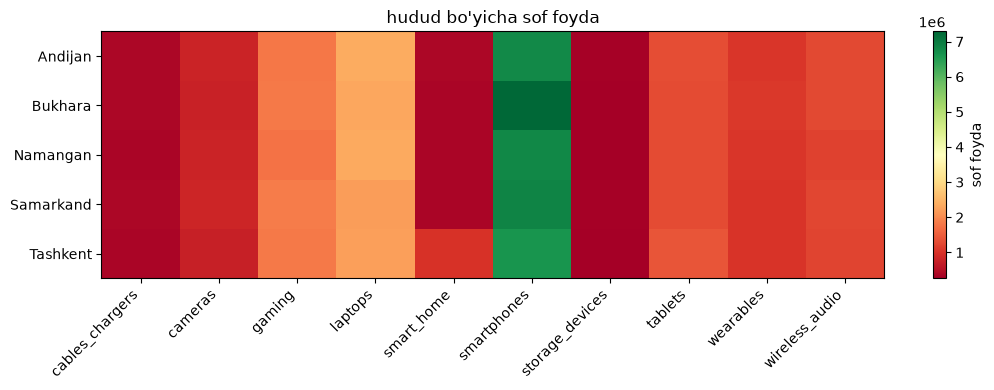

In [18]:
hudud = df.groupby(["region", "category"])["sof_foyda"].sum().reset_index()
pivot = hudud.pivot(index="region", columns="category", values="sof_foyda")

plt.figure(figsize=(11, 4))
plt.imshow(pivot.values, cmap="RdYlGn", aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="sof foyda")
plt.title("hudud bo'yicha sof foyda")
plt.tight_layout()
plt.show()

## Yakuniy xulosa

In [19]:
def qaror(f):
    if f >= 150:
        return "ko'proq ol"
    elif f >= 60:
        return "saqla"
    else:
        return "kamaytir"

kategoriya["tavsiya"] = kategoriya["birlik_foydasi"].apply(qaror)
kategoriya[["category", "sof_foyda", "birlik_foydasi", "tavsiya"]]

,category,sof_foyda,birlik_foydasi,tavsiya
5,smartphones,3.437457e+07,403.865098,ko'proq ol
3,laptops,1.143790e+07,597.435164,ko'proq ol
2,gaming,8.998896e+06,162.005071,ko'proq ol
7,tablets,6.596948e+06,239.514493,ko'proq ol
9,wireless_audio,6.171847e+06,68.126444,saqla
8,wearables,5.203932e+06,119.881408,saqla
1,cameras,3.933088e+06,333.453860,ko'proq ol
4,smart_home,2.443430e+06,87.997634,saqla
0,cables_chargers,1.853561e+06,11.033427,kamaytir
6,storage_devices,1.417718e+06,33.541169,kamaytir


Xulosa: smartfon va noutbuklarga ko'proq pul tikish kerak.
Kabel va xotira kabi tovarlar ko'p sotiladi, lekin foyda juda kam — ularni kamaytirgan ma'qul.

**Eslatma:** ma'lumotda tovarning sotib olish narxi (tannarx) yo'q, shuning uchun
marja foizi emas, balki sof foyda / birlik foydasi bo'yicha solishtirdik.

## Regression model

In [20]:
# regression model quramiz
# maqsad: sof foydani bashorat qilish

ml = df[["category", "region", "store_type", "year", "month", "avg_unit_price",
         "discount_pct", "promo_active", "customer_rating", "competitor_price_index",
         "marketing_spend", "sof_foyda"]].copy()

# promo_active ni 0/1 qilamiz
ml["promo_active"] = ml["promo_active"].map({True: 1, False: 0})

# bo'sh qiymatlarni to'ldiramiz
ml = ml.fillna(ml.mean(numeric_only=True))

# matnli ustunlarni 0/1 ga o'tkazamiz
ml = pd.get_dummies(ml, columns=["category", "region", "store_type"])

X = ml.drop("sof_foyda", axis=1)
y = ml["sof_foyda"]
print("X o'lchami:", X.shape)

X o'lchami: (2400, 26)


In [21]:
# train / test ajratamiz
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# avval oddiy chiziqli regressiya
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Linear  R2:", round(r2_score(y_test, pred_lr), 3))
print("Linear  MAE:", f"${mean_absolute_error(y_test, pred_lr):,.0f}")

Linear  R2: 0.947
Linear  MAE: $5,784


In [22]:
# random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("RandomForest  R2:", round(r2_score(y_test, pred_rf), 3))
print("RandomForest  MAE:", f"${mean_absolute_error(y_test, pred_rf):,.0f}")

RandomForest  R2: 0.963
RandomForest  MAE: $4,594


In [23]:
# qaysi omillar muhim ekanini ko'ramiz
importance = pd.DataFrame({
    "omil": X.columns,
    "ahamiyat": rf.feature_importances_
}).sort_values("ahamiyat", ascending=False)
importance.head(10)

,omil,ahamiyat
13,category_smartphones,0.803538
7,marketing_spend,0.083620
23,store_type_both,0.034488
2,avg_unit_price,0.021940
11,category_laptops,0.010685
3,discount_pct,0.010070
6,competitor_price_index,0.009821
10,category_gaming,0.007639
1,month,0.003958
5,customer_rating,0.003490


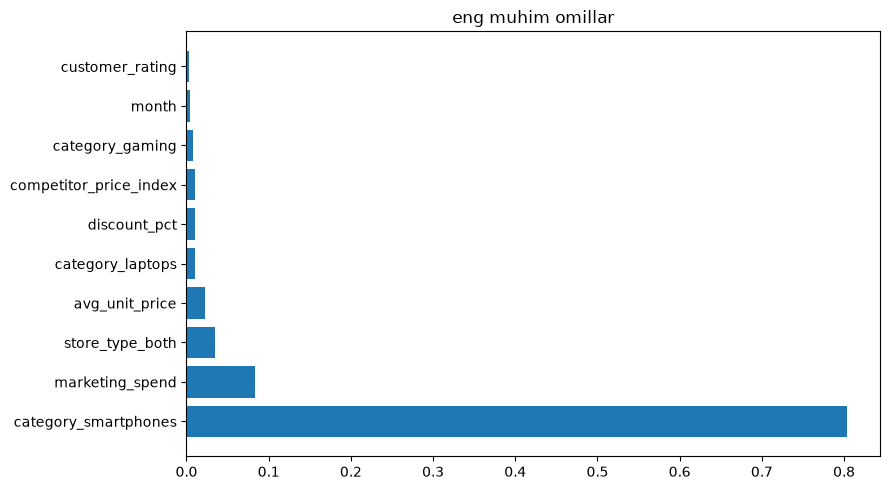

In [24]:
imp10 = importance.head(10)
plt.figure(figsize=(9, 5))
plt.barh(imp10["omil"], imp10["ahamiyat"])
plt.title("eng muhim omillar")
plt.tight_layout()
plt.show()

Model yaxshi ishlaydi (R2 ~0.96).
Eng muhim omil - kategoriya, keyin marketing xarajati.
Bu ham shuni ko'rsatadiki: foyda birinchi navbatda smartfonlar kategoriyasiga bog'liq.